# Hierarchical Clustering
* Hierarchical clustering is an unsupervised machine learning technique that groups data points into a tree-like hierarchy of nested clusters, visualized as a dendrogram
* It involves merging small clusters into larger ones **agglomerative**
* splitting large clusters into smaller ones **divisive** until the desired hierarchy is achieved.

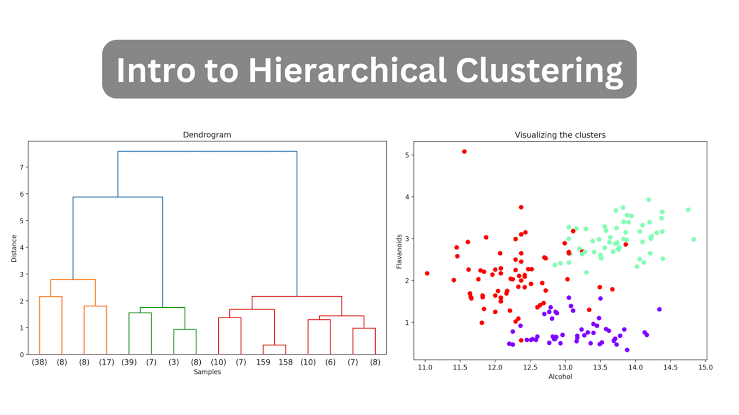

In [1]:
# Load the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px

In [2]:
# Load the dataset
df = pd.read_csv('/content/Mall_Customers.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Features of the data
* CustomerID - Unique ID assigned to the customer
* Gender - Gender of the customer
* Age - Age of the customer
* Annual Income - Annual Income of the customer
* Spending Sccore - Score assigned by the mall based on customer behavior and spending nature

In [3]:
# Info about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [4]:
# check for null values
df.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


No null values present in this dataset

In [5]:
# check for duplicates value
df.duplicated().sum()

np.int64(0)

No duplicate value present in this dataset

In [6]:
# checking statistical summury
df.describe()


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


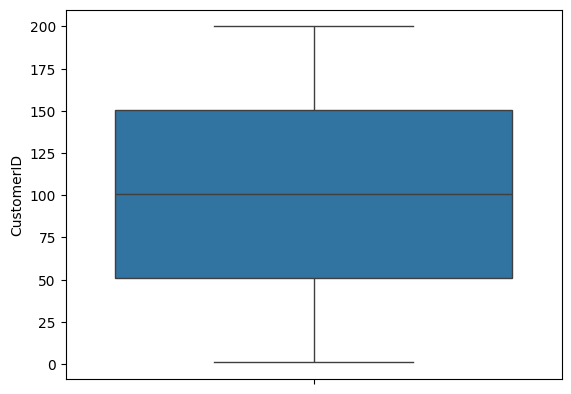

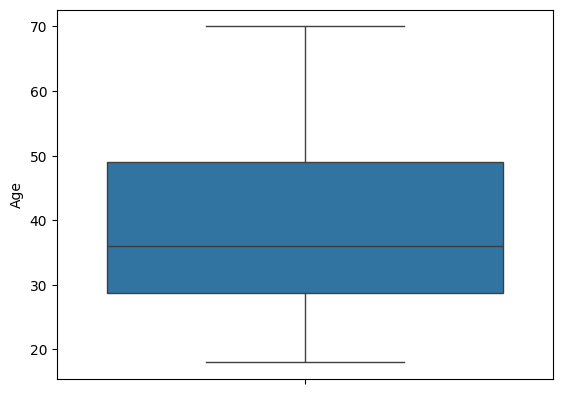

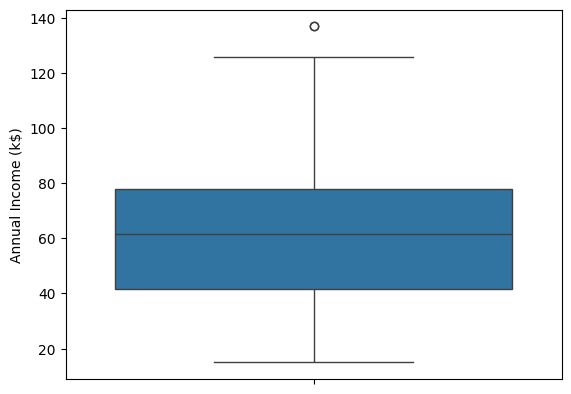

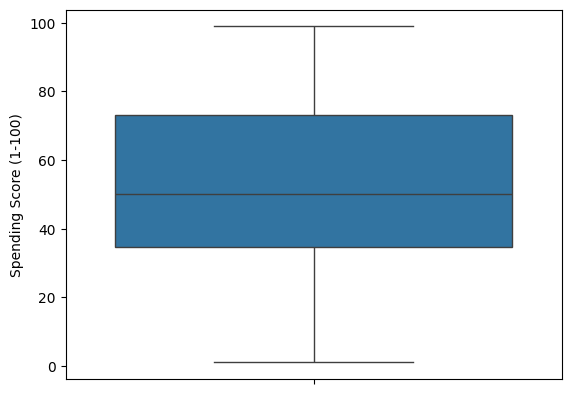

In [7]:
# checking outliers
for i in df.columns:
  if df[i].dtype != 'object':
    sns.boxplot(df[i])
    plt.show()

In [42]:
X = df.drop(['CustomerID','Gender'], axis=1)

In [43]:
X

,Age,Annual Income (k$),Spending Score (1-100),Cluster ID
0,19,15,39,2
1,21,15,81,2
2,20,16,6,2
3,23,16,77,2
4,31,17,40,2
...,...,...,...,...
195,35,120,79,1
196,45,126,28,0
197,32,126,74,1
198,32,137,18,0


In [40]:
# import the hierarchical cluster
import scipy.cluster.hierarchy as sc

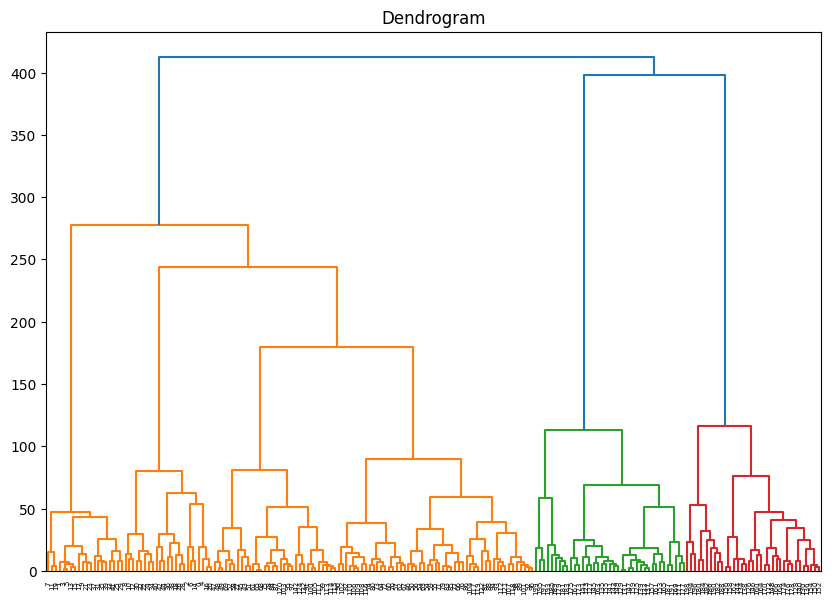

In [44]:
plt.figure(figsize=(10,7))
dendrogram = sc.dendrogram(sc.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.show()

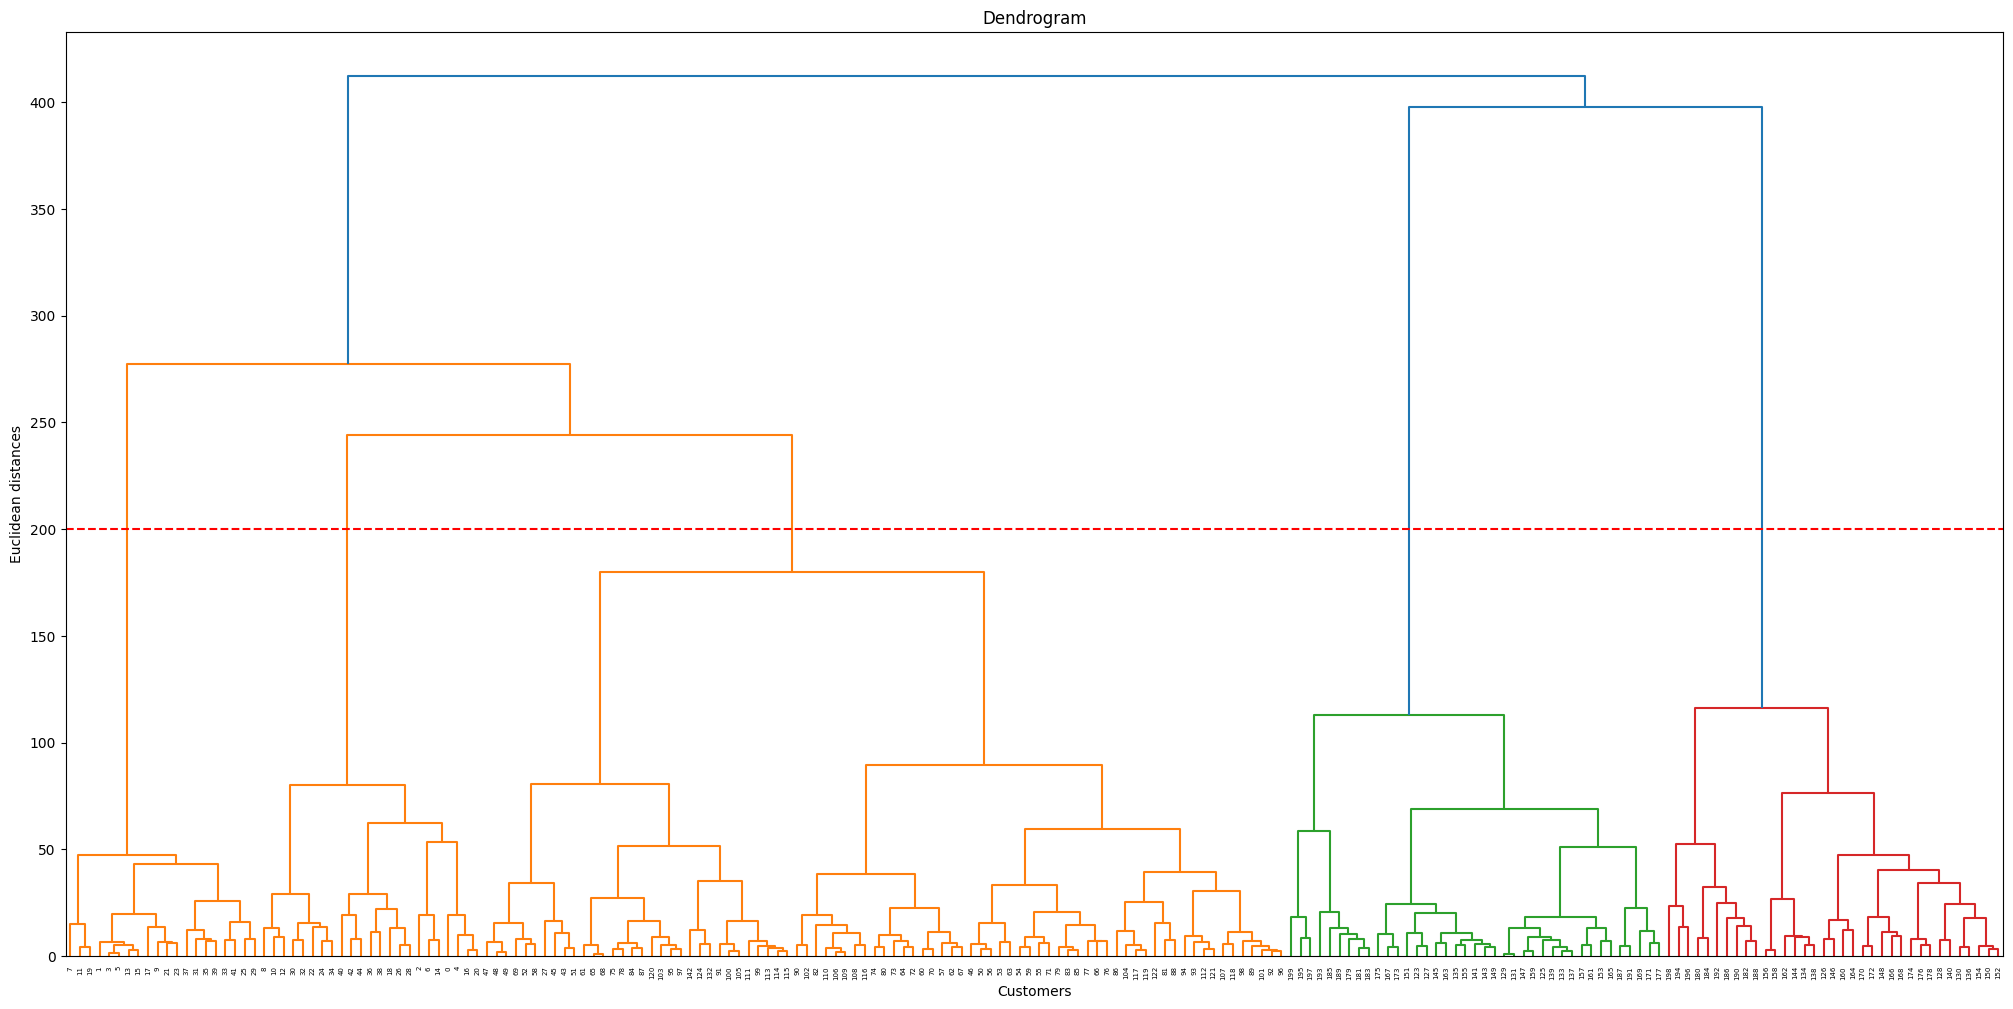

In [46]:
plt.figure(figsize=(25,12))
dendrogram = sc.dendrogram(sc.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Customers')
plt.ylabel('Euclidean distances')
plt.axhline(200, color='r', linestyle='--')
plt.show()

In [48]:
from sklearn.cluster import AgglomerativeClustering
Ach=AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
y_pred=Ach.fit_predict(X)

In [50]:
Cluster_Set=Ach.labels_
Cluster_Set

array([4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3,
       4, 3, 4, 3, 4, 0, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 3, 4, 0,
       4, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 1, 2, 1, 2, 1, 2,
       0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 0, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2, 1, 2,
       1, 2])

In [55]:
df=df.drop(['Cluster ID'], axis=1)
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster_Set
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
195,196,Female,35,120,79,2
196,197,Female,45,126,28,1
197,198,Male,32,126,74,2
198,199,Male,32,137,18,1


In [52]:
df['Cluster_Set']=Cluster_Set
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster ID,Cluster_Set
0,1,Male,19,15,39,2,4
1,2,Male,21,15,81,2,3
2,3,Female,20,16,6,2,4
3,4,Female,23,16,77,2,3
4,5,Female,31,17,40,2,4
...,...,...,...,...,...,...,...
195,196,Female,35,120,79,1,2
196,197,Female,45,126,28,0,1
197,198,Male,32,126,74,1,2
198,199,Male,32,137,18,0,1


In [56]:
fig=px.scatter_3d(df, x='Age', y='Annual Income (k$)', z='Spending Score (1-100)', color='Cluster_Set',opacity=0.8,hover_data=df)
fig.update_layout(margin=dict(l=0, r=0, t=0, b=0))
fig.show()
